# Ex. No: 12
# Face Detection with Haar Cascades

## **Name :** Ashqar Ahamed S T   **Reg. No :** 212224240018 

**Note: This is face *detection* NOT face *recognition*. We are only detecting if a face is in an image, not who the face actually is. That requires deep learning.**

## 1) Load and Display Images

- Step 1: Import necessary packages: numpy, cv2, matplotlib.pyplot
- Step 2: Load grayscale images using cv2.imread() with flag 0
- Step 3: Display images using plt.imshow() with cmap='gray'

In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
from IPython.display import clear_output

## Images

In [2]:

with_glass = cv2.imread('image_02.png')
with_out_glass = cv2.imread('image_01.png')
group_photo = cv2.imread('image_03.png')

with_glass = cv2.cvtColor(with_glass, cv2.COLOR_BGR2GRAY)
with_out_glass = cv2.cvtColor(with_out_glass, cv2.COLOR_BGR2GRAY)
group_photo = cv2.cvtColor(group_photo, cv2.COLOR_BGR2GRAY)


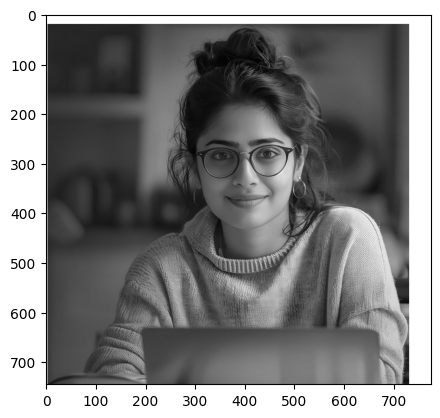

In [3]:
plt.imshow(with_glass,cmap='gray')

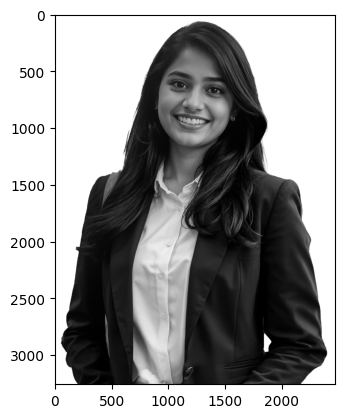

In [4]:
plt.imshow(with_out_glass,cmap='gray')

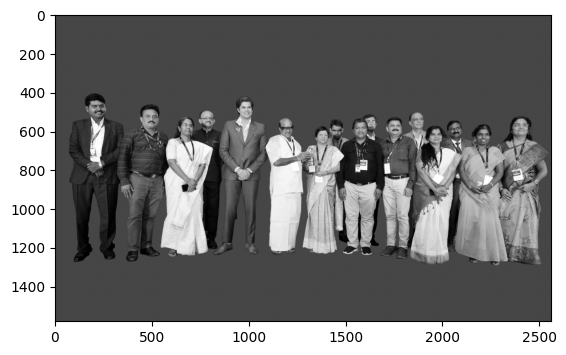

In [5]:
plt.imshow(group_photo,cmap='gray')

## II) Load Haar Cascade Classifiers

- Step 1: Load face and eye cascade XML files

## Face Detection

In [6]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

## III) Perform Face Detection in Images

- Step 1: Define a function detect_face() that copies the input image
- Step 2: Use face_cascade.detectMultiScale() to detect faces
- Step 3: Draw white rectangles around detected faces with thickness 10
- Step 4: Return the processed image with rectangles

In [7]:
def detect_face(img):
    faces = face_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5)

    for (x, y, w, h) in faces:
        cv2.rectangle(
            img,
            (x, y),
            (x+w, y+h),
            (255,255,255),
            3
        )

    
    return img
    

In [8]:
result = detect_face(with_glass)

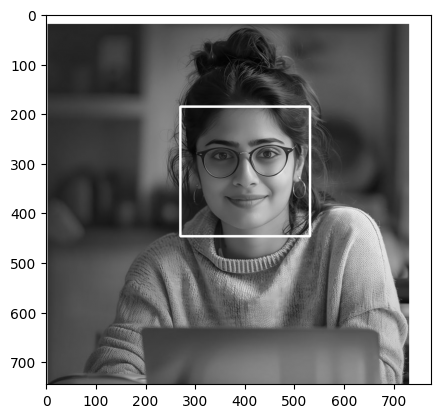

In [9]:
plt.imshow(result,cmap='gray')

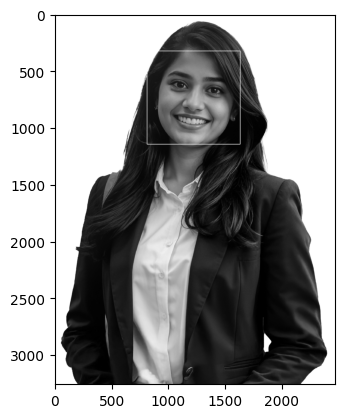

In [10]:
result = detect_face(with_out_glass)
plt.imshow(result,cmap='gray')

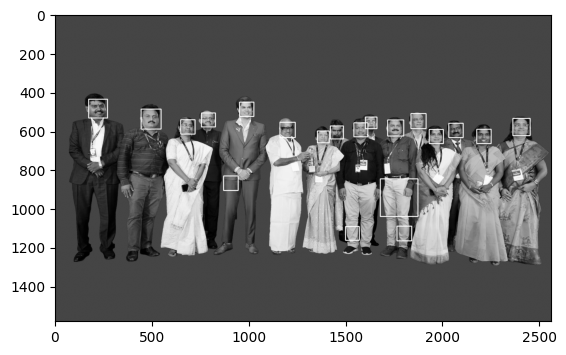

In [11]:
# Gets errors!
result = detect_face(group_photo)
plt.imshow(result,cmap='gray')

In [12]:
def adj_detect_face(img):

    faces = face_cascade.detectMultiScale(
        img,
        scaleFactor=1.05,
        minNeighbors=3,
        minSize=(30,30)
    )

    for (x, y, w, h) in faces:

        cv2.rectangle(
            img,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )
    
        
    return img
    

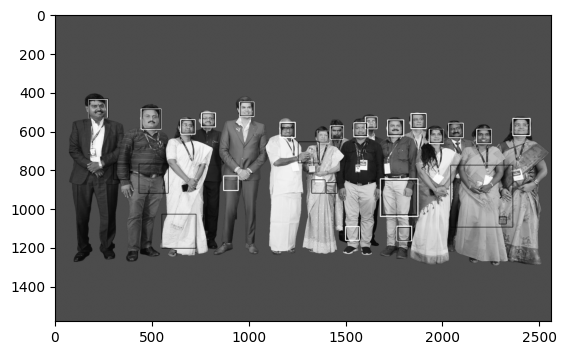

In [13]:
# Doesn't detect the side face.
result = adj_detect_face(group_photo)
plt.imshow(result,cmap='gray')

## IV) Perform Eye Detection in Images & Display Detection Results on Images

- Step 1: Define a function detect_eyes() that copies the input image
- Step 2: Use eye_cascade.detectMultiScale() to detect eyes
- Step 3: Draw white rectangles around detected eyes with thickness 10
- Step 4: Return the processed image with rectangles
- Step 5: Call detect_face() or detect_eyes() on loaded images
- Step 6: Use plt.imshow() with cmap='gray' to display images with detected regions highlighted

In [14]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

In [15]:
def detect_eyes(img):
    eyes = eye_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5)
    for (x, y, w, h) in eyes:
        cv2.rectangle(
            img,
            (x, y),
            (x+w, y+h),
            (255,255,255),
            3
        )
  
        
    return img
    

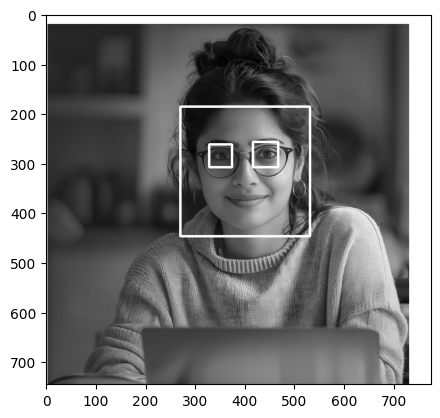

In [16]:
result = detect_eyes(with_glass)
plt.imshow(result,cmap='gray')

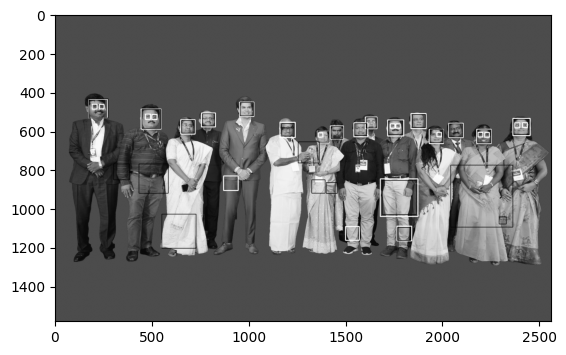

In [17]:
# White around the pupils is not distinct enough to detect eyes here!
result = detect_eyes(group_photo)
plt.imshow(result,cmap='gray')

## VI) Perform Face Detection on Real-Time Webcam Video

- Step 1: Capture video from webcam using cv2.VideoCapture(0)
- Step 2: Loop to continuously read frames from webcam
- Step 3: Apply detect_face() function on each frame
- Step 4: Display the video frame with rectangles around detected faces
- Step 5: Exit loop and close windows when ESC key (key code 27) is pressed
- Step 6: Release video capture and destroy all OpenCV windows

In [18]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    gray = detect_face(gray)

    cv2.imshow('Video Face Detection', gray)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()